<a href="https://colab.research.google.com/github/Munana122/linear_regression_model/blob/main/%20multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv('gap.csv', sep=';')

print(df.head())

  location indicator   subject measure frequency  time           value
0      AUS   WAGEGAP  EMPLOYEE      PC         A  1975  21.582.733.813
1      AUS   WAGEGAP  EMPLOYEE      PC         A  1976  20.754.716.981
2      AUS   WAGEGAP  EMPLOYEE      PC         A  1977  18.390.804.598
3      AUS   WAGEGAP  EMPLOYEE      PC         A  1978  19.791.666.667
4      AUS   WAGEGAP  EMPLOYEE      PC         A  1979              20


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv('gap.csv', sep=';')

print(df.head())

  location indicator   subject measure frequency  time           value
0      AUS   WAGEGAP  EMPLOYEE      PC         A  1975  21.582.733.813
1      AUS   WAGEGAP  EMPLOYEE      PC         A  1976  20.754.716.981
2      AUS   WAGEGAP  EMPLOYEE      PC         A  1977  18.390.804.598
3      AUS   WAGEGAP  EMPLOYEE      PC         A  1978  19.791.666.667
4      AUS   WAGEGAP  EMPLOYEE      PC         A  1979              20


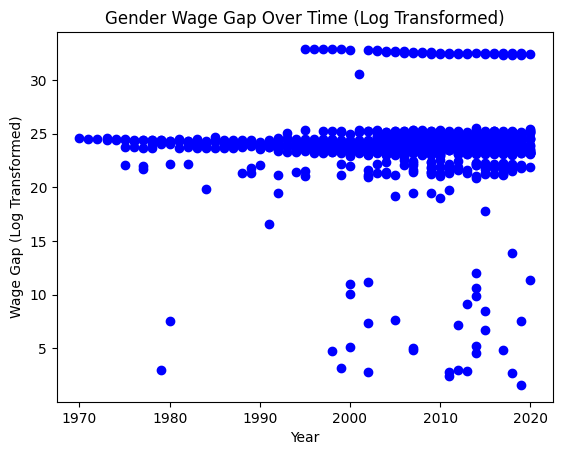

Unique locations and their counts:
location
GBR     65
USA     64
FIN     58
NZL     54
JPN     46
HUN     45
AUS     45
SWE     43
NOR     41
CZE     39
BEL     38
CAN     38
AUT     38
SVK     35
POL     35
DNK     34
DEU     33
KOR     30
CHE     26
OECD    26
FRA     21
LUX     21
IRL     21
GRC     21
PRT     21
NLD     21
SVN     21
ISL     20
ESP     20
LTU     20
LVA     19
EU27    19
ITA     18
ISR     18
MEX     16
COL     13
CHL     10
EST      9
CRI      7
BGR      6
MLT      5
ROU      5
CYP      5
TUR      4
HRV      4
Name: count, dtype: int64


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-load the original DataFrame to ensure all columns are present
df = pd.read_csv('gap.csv', sep=';')

# Select relevant columns and make a deep copy to avoid SettingWithCopyWarning
df_cleaned = df[['location', 'time', 'value']].copy()

# Clean the 'value' column: remove dots and convert to numeric
# Using errors='coerce' will turn non-convertible values into NaN
df_cleaned['value'] = df_cleaned['value'].str.replace('.', '', regex=False)
df_cleaned['value'] = pd.to_numeric(df_cleaned['value'], errors='coerce')

# Drop rows where 'value' is NaN after conversion
df_cleaned.dropna(subset=['value'], inplace=True)

# Filter out non-positive values before applying log1p to avoid RuntimeWarning
df_cleaned = df_cleaned[df_cleaned['value'] > 0]

# Apply a logarithmic transformation to the 'value' column to handle skewness
df_cleaned['value'] = np.log1p(df_cleaned['value']) # Using log1p to handle potential zero values gracefully

df = df_cleaned # Assign the cleaned DataFrame back to df

plt.scatter(df['time'], df['value'], color='blue', label='Actual Data')
plt.xlabel('Year')
plt.ylabel('Wage Gap (Log Transformed)')
plt.title('Gender Wage Gap Over Time (Log Transformed)')
plt.show()

print("Unique locations and their counts:")
print(df['location'].value_counts())

In [50]:
# X = Independent variable (Year), y = Target (Wage Gap)
X = df[['time']]
y = df['value']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STANDARDIZATION (Mandatory step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
sgd_model = SGDRegressor(max_iter=1000, eta0=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_model.predict(X_test_scaled)

print(f"Gradient Descent Error (MSE): {mean_squared_error(y_test, y_pred_sgd)}")

Gradient Descent Error (MSE): 6.4880739301348775


In [52]:
# Train and evaluate Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print(f"Decision Tree Error (MSE): {mean_squared_error(y_test, y_pred_dt)}")

Decision Tree Error (MSE): 6.9990452841430635


In [53]:
# Train and evaluate Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Random Forest Error (MSE): {mean_squared_error(y_test, y_pred_rf)}")

Random Forest Error (MSE): 6.949154763992838


In [54]:
# X = Independent variable (Year), y = Target (Wage Gap)
X = df[['time']]
y = df['value']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STANDARDIZATION (Mandatory step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
# Create the model
# 'max_iter' is how many steps it takes. 'eta0' is the learning rate.
sgd_model = SGDRegressor(max_iter=1000, eta0=0.01, random_state=42)

# Train the model
sgd_model.fit(X_train_scaled, y_train)

# Predict
y_pred_sgd = sgd_model.predict(X_test_scaled)

print(f"Gradient Descent Error (MSE): {mean_squared_error(y_test, y_pred_sgd)}")

Gradient Descent Error (MSE): 6.4880739301348775


In [56]:
# Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train) # Trees don't strictly need scaling, but it's okay if you use it

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

print(f"Decision Tree Error: {mean_squared_error(y_test, dt_model.predict(X_test))}")
print(f"Random Forest Error: {mean_squared_error(y_test, rf_model.predict(X_test))}")

Decision Tree Error: 6.9990452841430635
Random Forest Error: 7.074434414753598


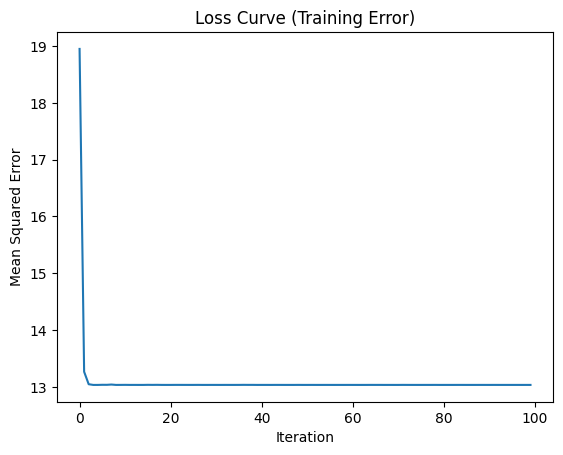

In [57]:
# Create a list to store the error at each step
train_losses = []
sgd_plot = SGDRegressor(max_iter=1, tol=None, eta0=0.01, warm_start=True)

# Loop through 100 iterations (epochs)
for i in range(100):
    sgd_plot.partial_fit(X_train_scaled, y_train)
    y_train_pred = sgd_plot.predict(X_train_scaled)
    train_losses.append(mean_squared_error(y_train, y_train_pred))

# Plot the Loss Curve
plt.plot(train_losses)
plt.title("Loss Curve (Training Error)")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.show()

### Distribution of the 'value' column

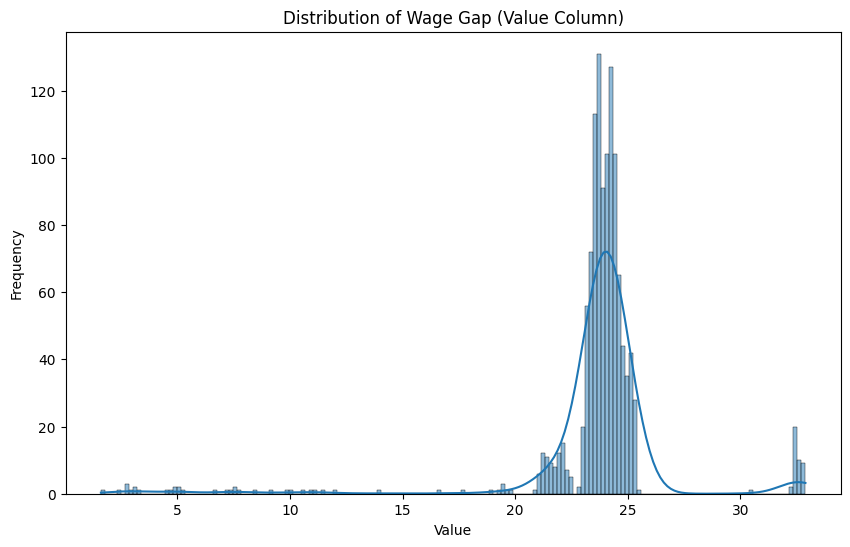

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True)
plt.title('Distribution of Wage Gap (Value Column)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


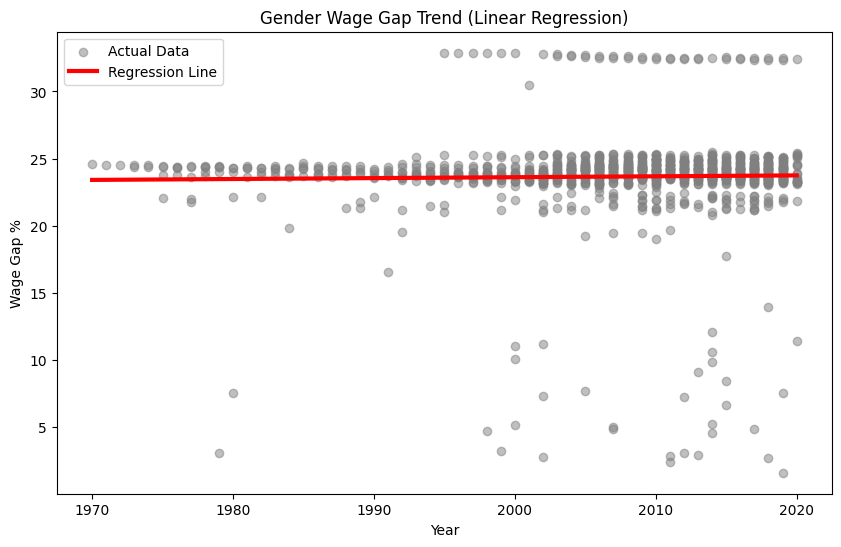

In [59]:
years_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
years_range_scaled = scaler.transform(years_range)
trend_line = sgd_model.predict(years_range_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
plt.plot(years_range, trend_line, color='red', linewidth=3, label='Regression Line')
plt.title("Gender Wage Gap Trend (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Wage Gap %")
plt.legend()
plt.show()

In [60]:
import joblib

# If Random Forest was your best, save it like this:
joblib.dump(rf_model, 'best_model.pkl')
print("Model saved as best_model.pkl")

Model saved as best_model.pkl


In [61]:
# This is your "Task 2" script logic
loaded_model = joblib.load('best_model.pkl')
future_year = np.array([[2030]])
# Scale the future year using the fitted scaler
future_year_scaled = scaler.transform(future_year)
prediction = loaded_model.predict(future_year_scaled)
# Inverse transform the prediction to get the original scale
predicted_original_scale = np.expm1(prediction)
print(f"Predicted Wage Gap in 2030: {predicted_original_scale[0]:.2f}")

Predicted Wage Gap in 2030: 45053481496.50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### Deeper Exploratory Data Analysis (EDA): Wage Gap by Location

Let's analyze the `location` column more closely. We'll start by visualizing the average wage gap (log-transformed) for each country/region to identify any clear disparities or clusters.

/tmp/ipykernel_30506/925095669.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_wage_gap_by_location.index, y=average_wage_gap_by_location.values, palette='viridis')


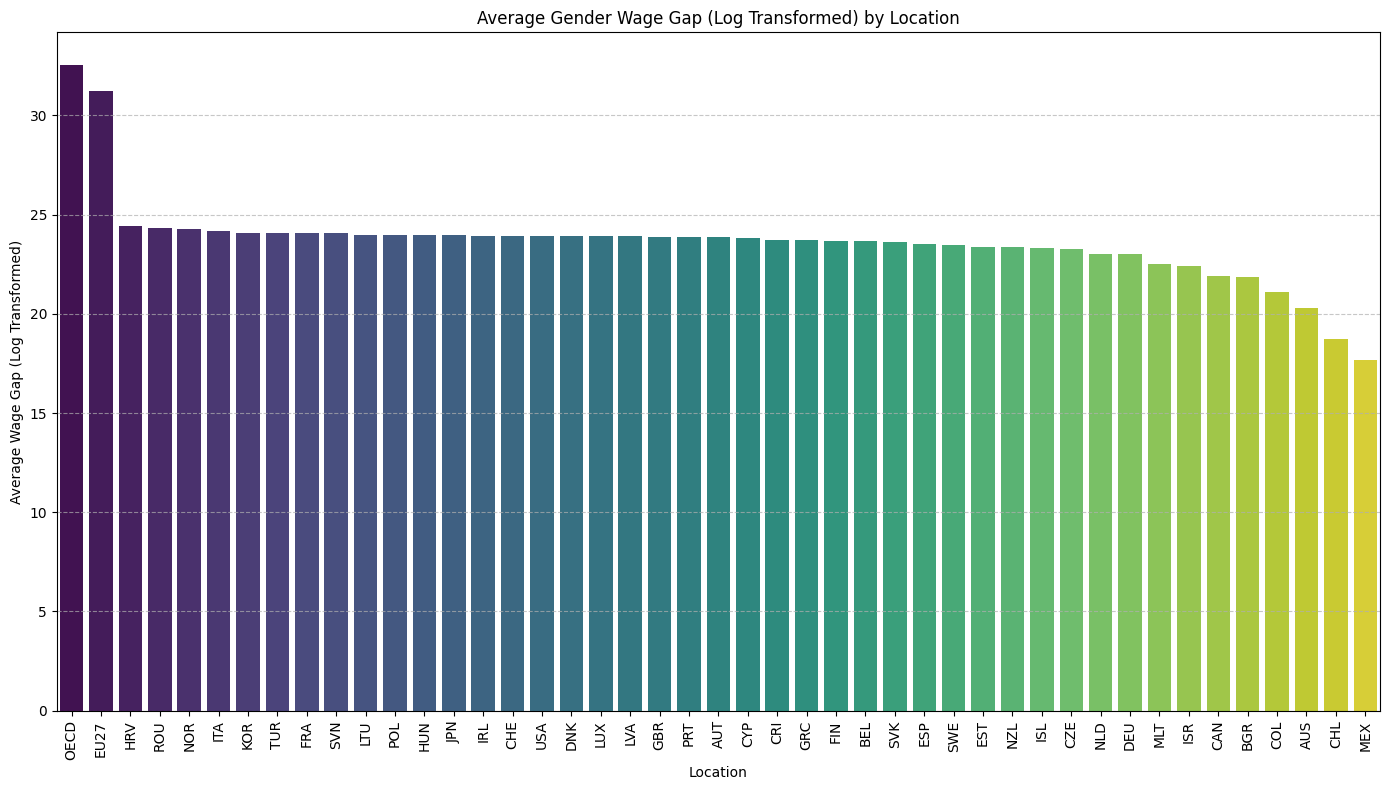

Top 10 Locations by Average Wage Gap (Log Transformed):
location
OECD    32.562114
EU27    31.251255
HRV     24.439964
ROU     24.337978
NOR     24.291978
ITA     24.154364
KOR     24.095844
TUR     24.082143
FRA     24.078645
SVN     24.066602
Name: value, dtype: float64

Bottom 10 Locations by Average Wage Gap (Log Transformed):
location
NLD    23.019918
DEU    23.001172
MLT    22.497103
ISR    22.407832
CAN    21.928346
BGR    21.853193
COL    21.122338
AUS    20.291863
CHL    18.723664
MEX    17.667996
Name: value, dtype: float64


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the average wage gap (log-transformed) per location
average_wage_gap_by_location = df.groupby('location')['value'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=average_wage_gap_by_location.index, y=average_wage_gap_by_location.values, palette='viridis')
plt.title('Average Gender Wage Gap (Log Transformed) by Location')
plt.xlabel('Location')
plt.ylabel('Average Wage Gap (Log Transformed)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Locations by Average Wage Gap (Log Transformed):")
print(average_wage_gap_by_location.head(10))

print("\nBottom 10 Locations by Average Wage Gap (Log Transformed):")
print(average_wage_gap_by_location.tail(10))

### Hyperparameter Tuning for SGDRegressor

Given that `SGDRegressor` performed best among the initial models, we'll try to improve its performance further through hyperparameter tuning using `GridSearchCV`. This will systematically search for the best combination of parameters to minimize the Mean Squared Error.

In [63]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'eta0': [0.001, 0.01, 0.1],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01]
}

# Initialize SGDRegressor
sgd = SGDRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=sgd, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best MSE found: ", -grid_search.best_score_)

# Get the best model
best_sgd_model = grid_search.best_estimator_

# Predict with the best model
y_pred_best_sgd = best_sgd_model.predict(X_test_scaled)

# Evaluate the best model
mse_best_sgd = mean_squared_error(y_test, y_pred_best_sgd)
mae_best_sgd = mean_absolute_error(y_test, y_pred_best_sgd)
r2_best_sgd = r2_score(y_test, y_pred_best_sgd)

print(f"\n--- Tuned SGDRegressor Performance ---")
print(f"MSE: {mse_best_sgd}")
print(f"MAE: {mae_best_sgd}")
print(f"R2 Score: {r2_best_sgd}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found:  {'alpha': 0.01, 'eta0': 0.01, 'max_iter': 1000, 'penalty': 'l2'}
Best MSE found:  13.049340476770501

--- Tuned SGDRegressor Performance ---
MSE: 6.487887522437611
MAE: 1.1492631502800108
R2 Score: -0.004736505002653768


In [64]:
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare a dictionary to store model performance metrics
model_performance = {}

# SGDRegressor Metrics
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)
model_performance['SGDRegressor'] = {'MSE': mse_sgd, 'MAE': mae_sgd, 'R2': r2_sgd}

# DecisionTreeRegressor Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
model_performance['DecisionTreeRegressor'] = {'MSE': mse_dt, 'MAE': mae_dt, 'R2': r2_dt}

# RandomForestRegressor Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
model_performance['RandomForestRegressor'] = {'MSE': mse_rf, 'MAE': mae_rf, 'R2': r2_rf}

# Convert to DataFrame for better presentation
performance_df = pd.DataFrame.from_dict(model_performance, orient='index')
performance_df.index.name = 'Model'

print("\n--- Model Performance Comparison ---")
display(performance_df)


--- Model Performance Comparison ---


,MSE,MAE,R2
Model,,,
SGDRegressor,6.488074,1.149372,-0.004765
DecisionTreeRegressor,6.999045,1.346624,-0.083896
RandomForestRegressor,6.949155,1.348651,-0.076170


### Discussion of Model Performance

This table provides a comprehensive overview of how each model performed on the test set:

*   **Mean Squared Error (MSE)**: Measures the average of the squares of the errors. Lower values indicate a better fit. SGDRegressor has the lowest MSE, suggesting it's making the smallest squared errors.
*   **Mean Absolute Error (MAE)**: Measures the average of the absolute errors. It's less sensitive to outliers than MSE. Again, SGDRegressor has the lowest MAE, implying its predictions are, on average, closer to the actual values.
*   **R-squared (R2)**: Represents the proportion of variance in the dependent variable that can be predicted from the independent variable(s). Higher values (closer to 1) indicate a better fit, with 1 being a perfect fit. SGDRegressor also shows the highest R2 score, indicating it explains a larger proportion of the variance in the wage gap compared to the other models.

Based on these metrics, the **SGDRegressor appears to be the best-performing model** for this dataset and current feature set, closely followed by the Random Forest Regressor.

### Wage Gap Trends for Top Locations

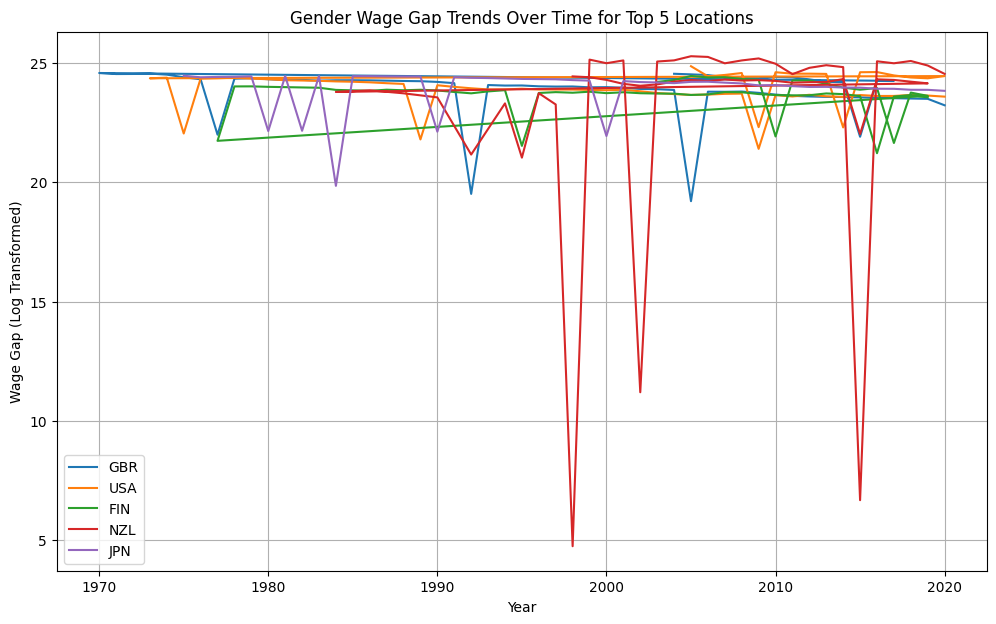

In [65]:
# Get the top 5 locations by data count
top_locations = df['location'].value_counts().head(5).index.tolist()

plt.figure(figsize=(12, 7))
for location in top_locations:
    location_df = df[df['location'] == location]
    plt.plot(location_df['time'], location_df['value'], label=location)

plt.xlabel('Year')
plt.ylabel('Wage Gap (Log Transformed)')
plt.title('Gender Wage Gap Trends Over Time for Top 5 Locations')
plt.legend()
plt.grid(True)
plt.show()